# 03 · Modelación Predictiva
**TFM: Análisis y Predicción de la Extorsión en Colombia**

Este script entrena y evalúa cuatro modelos de regresión para predecir la tasa
de extorsión a nivel municipal-mensual. Genera las ilustraciones 21–26 del TFM
y exporta la tabla comparativa de métricas.

**Input**:
- `datos/gold/consolidado_modelado.csv` (16.869 registros, 2020–2025)

**Outputs**:
- `outputs/modelacion/figuras/ILUSTRACION_21–26.png`
- `outputs/modelacion/metricas/comparacion_modelos.csv`

---
### Decisiones metodológicas justificadas
1. **División temporal** (no aleatoria): Train 2020–2023 / Test 2024–2025.
   Evita data leakage y simula el uso operativo real del modelo.
2. **Sin `cod_mun`**: >1.046 categorías generarían >1.000 dummies innecesarias.
   Los efectos municipales quedan parcialmente capturados por `poblacion_total`.
3. **Con `cod_dpto`**: Solo 33 categorías; captura efectos regionales estructurales.
4. **Sin variables lag**: Las pruebas previas mostraron VIF > 100, señal de
   multicolinealidad severa que degradaba la interpretabilidad del modelo.
5. **Gradient Boosting como modelo final**: Mejor R² Test (0.8046) con el menor
   diferencial de sobreajuste entre modelos de ensemble (13.3% vs. 18.7% de RF).


## 1. Configuración e Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
from scipy import stats

from sklearn.linear_model  import LinearRegression
from sklearn.ensemble      import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose       import ColumnTransformer
from sklearn.pipeline      import Pipeline
from sklearn.metrics       import mean_absolute_error, mean_squared_error, r2_score
from xgboost               import XGBRegressor

warnings.filterwarnings('ignore')

# ── Rutas ─────────────────────────────────────────────────────────────────────
GOLD_PATH    = 'datos/gold'
FIGURAS_PATH = 'outputs/modelacion/figuras'
METRICAS_PATH = 'outputs/modelacion/metricas'

os.makedirs(FIGURAS_PATH,  exist_ok=True)
os.makedirs(METRICAS_PATH, exist_ok=True)

# ── Estilo visual ─────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 300, 'font.size': 11, 'font.family': 'DejaVu Sans'})

print("[OK] Configuración lista")
print(f"     Figuras  → {FIGURAS_PATH}/")
print(f"     Métricas → {METRICAS_PATH}/")

[OK] Configuración lista
     Figuras  → outputs/modelacion/figuras/
     Métricas → outputs/modelacion/metricas/



## 2. Carga y División Temporal de Datos

**Criterio de partición**: Los 16.869 registros se dividen por año, no de forma
aleatoria. Esta estrategia respeta la estructura temporal de los datos y garantiza
que el modelo nunca vea información "del futuro" durante el entrenamiento.

| Conjunto | Período    | Registros | % del total |
|----------|-----------|-----------|-------------|
| Train    | 2020–2023 | 10.487    | 62.2%       |
| Test     | 2024–2025 | 6.382     | 37.8%       |


In [2]:
df = pd.read_csv(f'{GOLD_PATH}/consolidado_modelado.csv')
print(f"Dataset cargado: {len(df):,} registros ({df['ano'].min()}–{df['ano'].max()})")

# Variable objetivo
target = 'total_extorsion'

# Variables categóricas y numéricas
cat_features = ['cod_dpto']
num_features  = ['poblacion_total', 'total_homicidio', 'total_hurto',
                 'total_terrorismo', 'incautaciones_total', 'cantidad_total_kg']

# División temporal
train_mask = df['ano'] <= 2023
test_mask  = df['ano'] >= 2024

X_train = df[train_mask][cat_features + num_features].copy()
y_train = df[train_mask][target].copy()
X_test  = df[test_mask][cat_features + num_features].copy()
y_test  = df[test_mask][target].copy()

# Imputar nulos en predictoras con la mediana del conjunto de entrenamiento
for col in num_features:
    if X_train[col].isnull().sum() > 0:
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)
        X_test[col].fillna(median_val, inplace=True)

print(f"\nDivisión temporal:")
print(f"  Train 2020–2023 : {len(X_train):>7,} registros ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Test  2024–2025 : {len(X_test):>7,}  registros ({len(X_test)/len(df)*100:.1f}%)")
print(f"\nVariable objetivo — Train: media={y_train.mean():.2f}, max={y_train.max()}")
print(f"Variable objetivo — Test : media={y_test.mean():.2f}, max={y_test.max()}")

Dataset cargado: 16,869 registros (2020–2025)

División temporal:
  Train 2020–2023 :  10,487 registros (62.2%)
  Test  2024–2025 :   6,382  registros (37.8%)

Variable objetivo — Train: media=3.57, max=308
Variable objetivo — Test : media=4.07, max=271



## 3. Ilustración 21: Distribución Train vs. Test


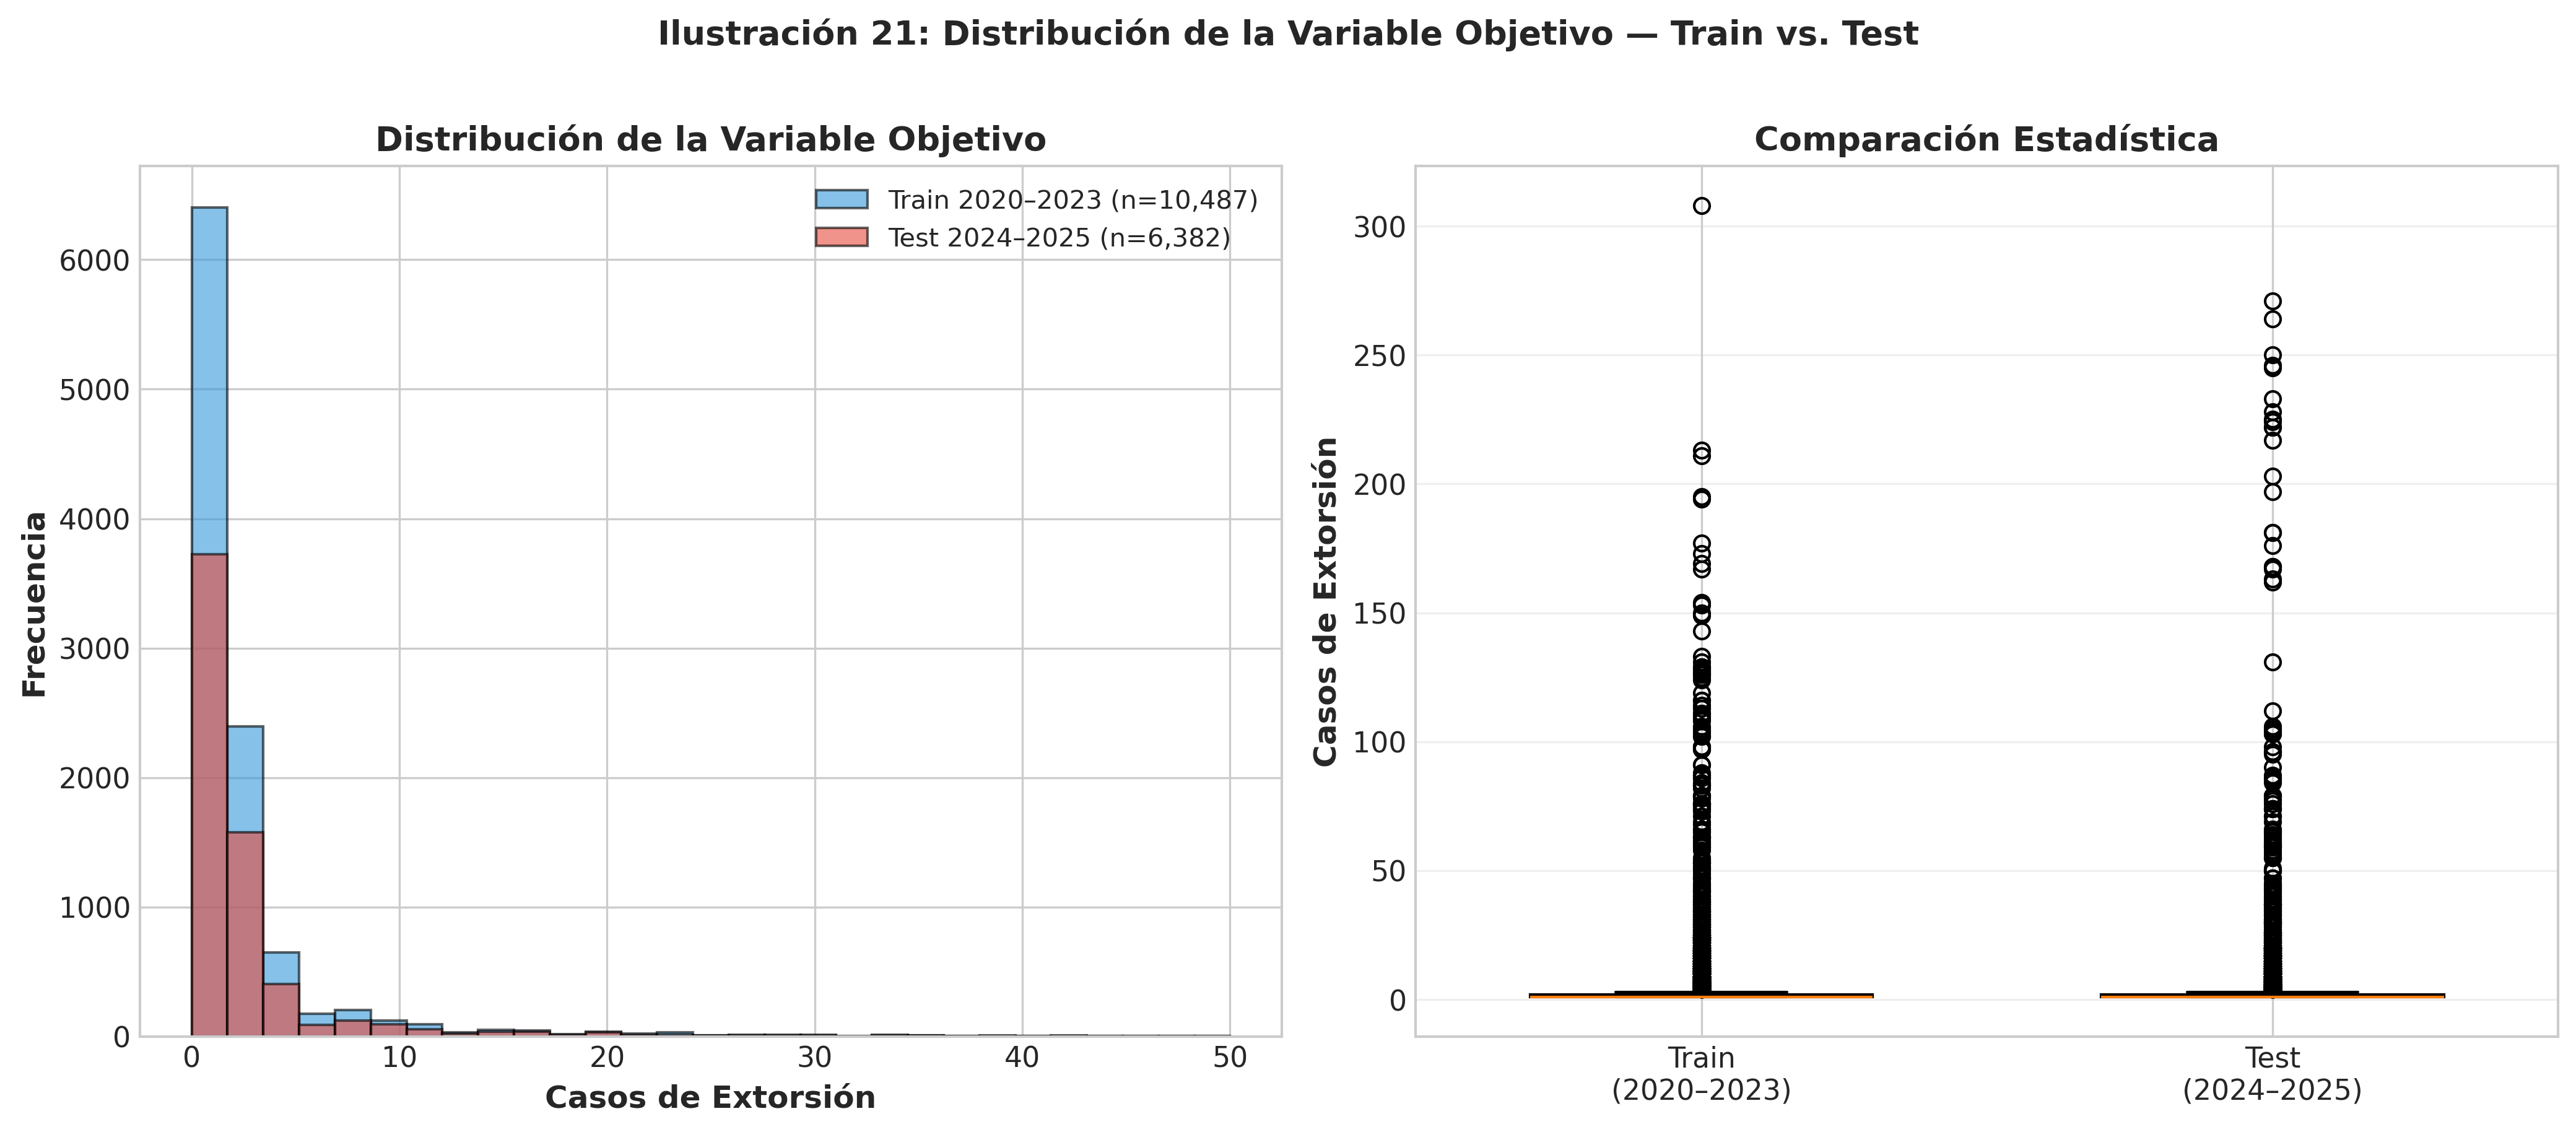

Guardado: ILUSTRACION_21_distribucion_train_test.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma
ax = axes[0]
bins = np.linspace(0, 50, 30)
ax.hist(y_train, bins=bins, alpha=0.6, label=f'Train 2020–2023 (n={len(y_train):,})',
        color='#3498db', edgecolor='black')
ax.hist(y_test, bins=bins, alpha=0.6, label=f'Test 2024–2025 (n={len(y_test):,})',
        color='#e74c3c', edgecolor='black')
ax.set_xlabel('Casos de Extorsión', fontsize=12, fontweight='bold')
ax.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
ax.set_title('Distribución de la Variable Objetivo', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Boxplot comparativo
ax = axes[1]
bp = ax.boxplot([y_train, y_test], labels=['Train\n(2020–2023)', 'Test\n(2024–2025)'],
                patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')
ax.set_ylabel('Casos de Extorsión', fontsize=12, fontweight='bold')
ax.set_title('Comparación Estadística', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.suptitle('Ilustración 21: Distribución de la Variable Objetivo — Train vs. Test',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURAS_PATH}/ILUSTRACION_21_distribucion_train_test.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: ILUSTRACION_21_distribucion_train_test.png")


## 4. Pipeline de Preprocesamiento

Se implementa un `Pipeline` de scikit-learn para garantizar que el mismo
preprocesamiento se aplique de forma idéntica en entrenamiento y predicción,
eliminando el riesgo de inconsistencias manuales.

- **`OneHotEncoder`**: Convierte `cod_dpto` (33 categorías) en variables binarias.
- **`StandardScaler`**: Normaliza las 6 variables numéricas (media=0, std=1).
  Necesario porque las magnitudes son muy dispares (ej: población en millones vs.
  terrorismo en unidades).
- **`SimpleImputer`**: Salvaguarda preventiva para posibles nulos residuales.


In [4]:
numeric_transformer    = Pipeline([('scaler', StandardScaler())])
categorical_transformer = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     num_features),
    ('cat', categorical_transformer, cat_features)
])

print("[OK] Pipeline de preprocesamiento definido")
print(f"     Numéricas ({len(num_features)}): {num_features}")
print(f"     Categóricas ({len(cat_features)}): {cat_features}")

[OK] Pipeline de preprocesamiento definido
     Numéricas (6): ['poblacion_total', 'total_homicidio', 'total_hurto', 'total_terrorismo', 'incautaciones_total', 'cantidad_total_kg']
     Categóricas (1): ['cod_dpto']



## 5. Entrenamiento de los 4 Modelos

Se comparan cuatro enfoques para responder: ¿justifica la complejidad de los
modelos de ensamble la mejora respecto a un baseline lineal?

| Modelo | Enfoque | Justificación |
|--------|---------|---------------|
| Regresión Lineal | Baseline paramétrico | Establece piso de rendimiento |
| Random Forest | Ensamble bagging | Robusto a outliers, alta capacidad |
| Gradient Boosting | Ensamble boosting secuencial | Mejor R² / overfitting controlado |
| XGBoost | Boosting optimizado con regularización L1/L2 | Alternativa eficiente |


In [5]:
modelos = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42,
                                                n_jobs=-1, max_depth=15),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42,
                                                    learning_rate=0.1, max_depth=3),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1,
                                       learning_rate=0.1, max_depth=3, verbosity=0),
}

resultados = {}
modelos_entrenados = {}

print("Entrenando modelos...")
print("-" * 65)

for nombre, modelo in modelos.items():
    t0 = time.time()
    pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', modelo)])
    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred  = pipeline.predict(X_test)

    resultados[nombre] = {
        'train_pred': y_train_pred,
        'test_pred':  y_test_pred,
        'train_mae':  mean_absolute_error(y_train, y_train_pred),
        'test_mae':   mean_absolute_error(y_test,  y_test_pred),
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'test_rmse':  np.sqrt(mean_squared_error(y_test,  y_test_pred)),
        'train_r2':   r2_score(y_train, y_train_pred),
        'test_r2':    r2_score(y_test,  y_test_pred),
        'tiempo':     time.time() - t0
    }
    modelos_entrenados[nombre] = pipeline
    r = resultados[nombre]
    print(f"  {nombre:<22}  Train R²={r['train_r2']:.4f}  Test R²={r['test_r2']:.4f}"
          f"  MAE={r['test_mae']:.2f}  ({r['tiempo']:.0f}s)")

Entrenando modelos...
-----------------------------------------------------------------
  Linear Regression       Train R²=0.7903  Test R²=0.7647  MAE=2.12  (0s)
  Random Forest           Train R²=0.9778  Test R²=0.7916  MAE=1.59  (1s)
  Gradient Boosting       Train R²=0.9363  Test R²=0.7975  MAE=1.70  (2s)
  XGBoost                 Train R²=0.9121  Test R²=0.7737  MAE=1.76  (0s)



## 6. Tabla de Resultados — Métricas Comparativas


In [6]:
# Construir tabla comparativa (coincide con Tabla 9.1 y 9.2 del TFM)
tabla = pd.DataFrame({
    nombre: {
        'Train MAE':  round(r['train_mae'],  4),
        'Test MAE':   round(r['test_mae'],   4),
        'Train RMSE': round(r['train_rmse'], 4),
        'Test RMSE':  round(r['test_rmse'],  4),
        'Train R2':   round(r['train_r2'],   4),
        'Test R2':    round(r['test_r2'],    4),
        'Diferencia R2 (%)': round((r['train_r2'] - r['test_r2']) * 100, 2),
    }
    for nombre, r in resultados.items()
}).T

tabla_path = f'{METRICAS_PATH}/comparacion_modelos.csv'
tabla.to_csv(tabla_path)

print("=" * 65)
print("RESULTADOS FINALES — TEST SET")
print("=" * 65)
tabla_test = tabla[['Test MAE', 'Test RMSE', 'Test R2', 'Diferencia R2 (%)']].sort_values('Test R2', ascending=False)
print(tabla_test.to_string())
print()
print(f"Mejor modelo: {tabla_test.index[0]}  (R² Test = {tabla_test['Test R2'].iloc[0]:.4f})")
print(f"Guardado en : {tabla_path}")

RESULTADOS FINALES — TEST SET
                   Test MAE  Test RMSE  Test R2  Diferencia R2 (%)
Gradient Boosting    1.7009     6.6257   0.7975              13.88
Random Forest        1.5869     6.7212   0.7916              18.62
XGBoost              1.7550     7.0035   0.7737              13.84
Linear Regression    2.1155     7.1421   0.7647               2.56

Mejor modelo: Gradient Boosting  (R² Test = 0.7975)
Guardado en : outputs/modelacion/metricas/comparacion_modelos.csv



## 7. Ilustraciones 22–24: Predicciones Reales vs. Predichas

Se grafican los valores reales contra las predicciones para cada modelo,
tanto en entrenamiento como en prueba. La diagonal (línea roja punteada)
representa la predicción perfecta; la dispersión respecto a ella indica el error.


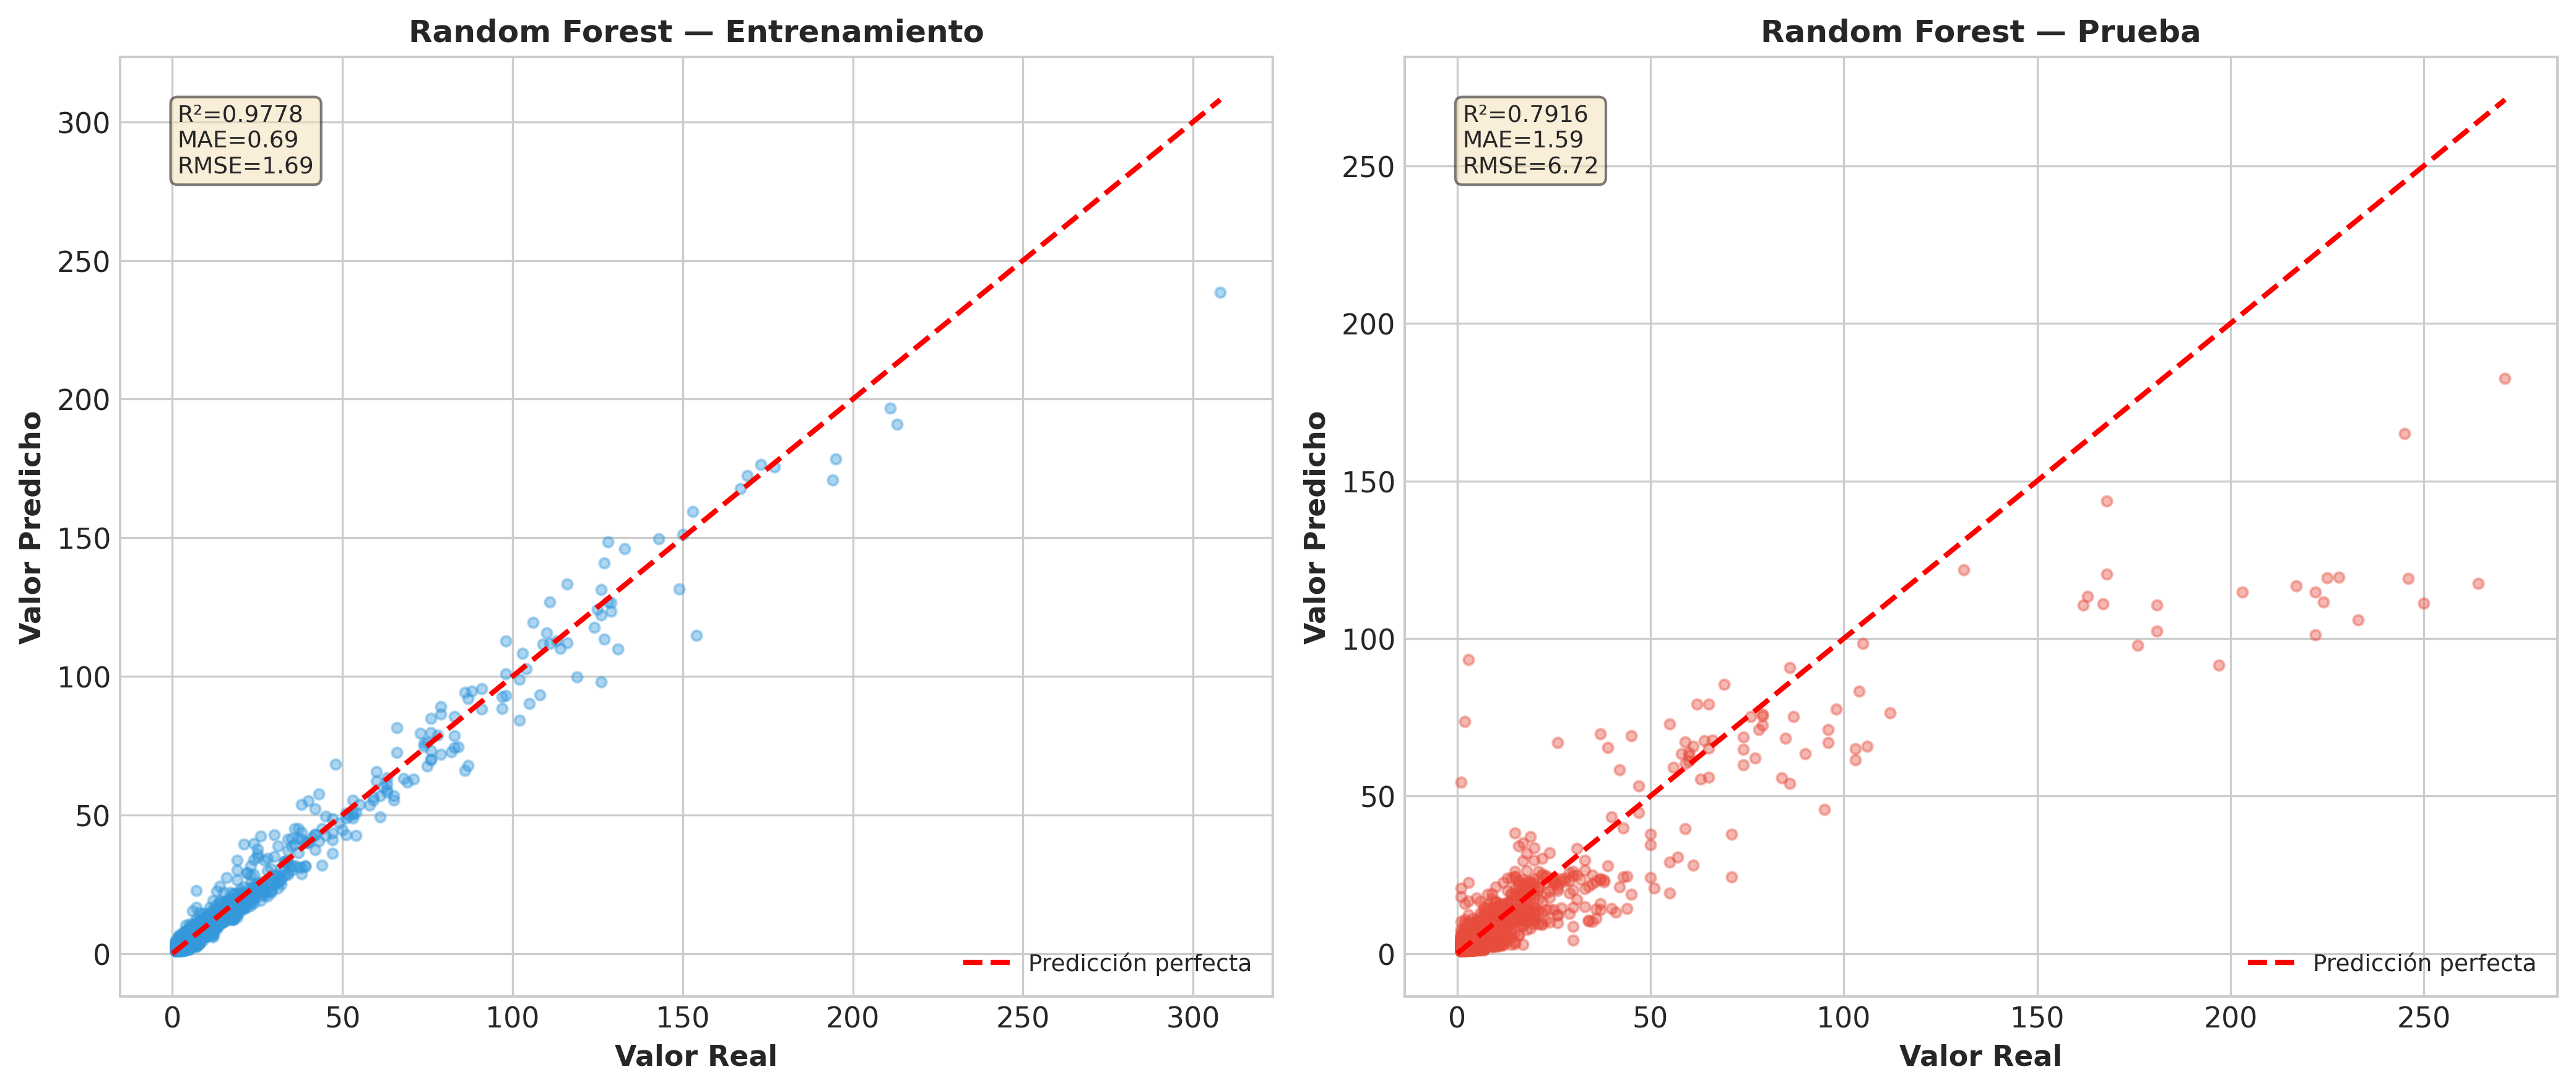

Guardado: ILUSTRACION_23_predicciones_random_forest.png


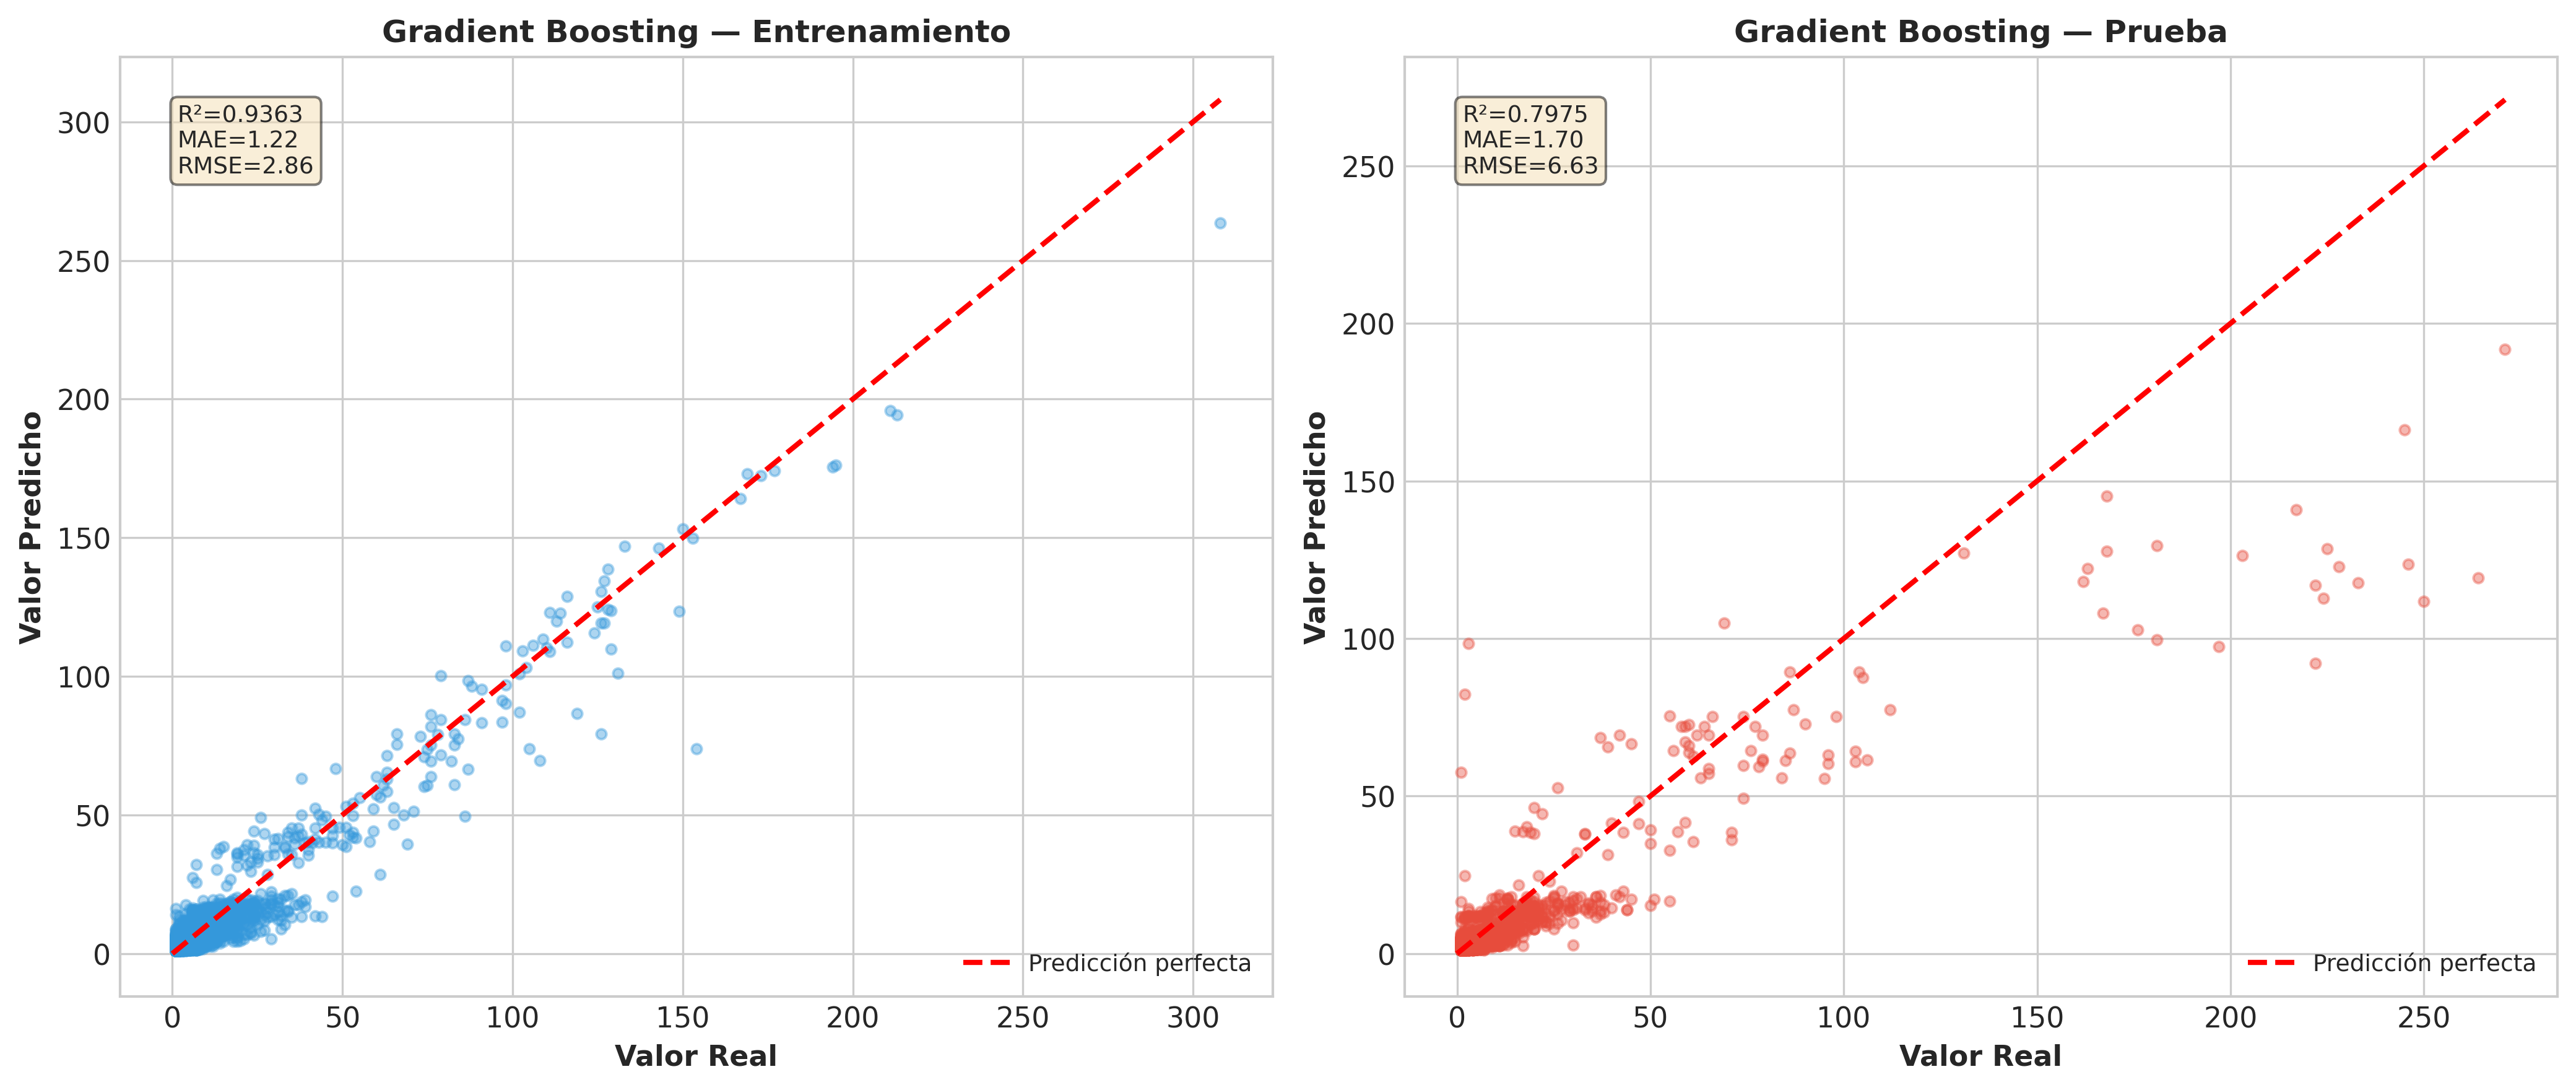

Guardado: ILUSTRACION_24_predicciones_gradient_boosting.png


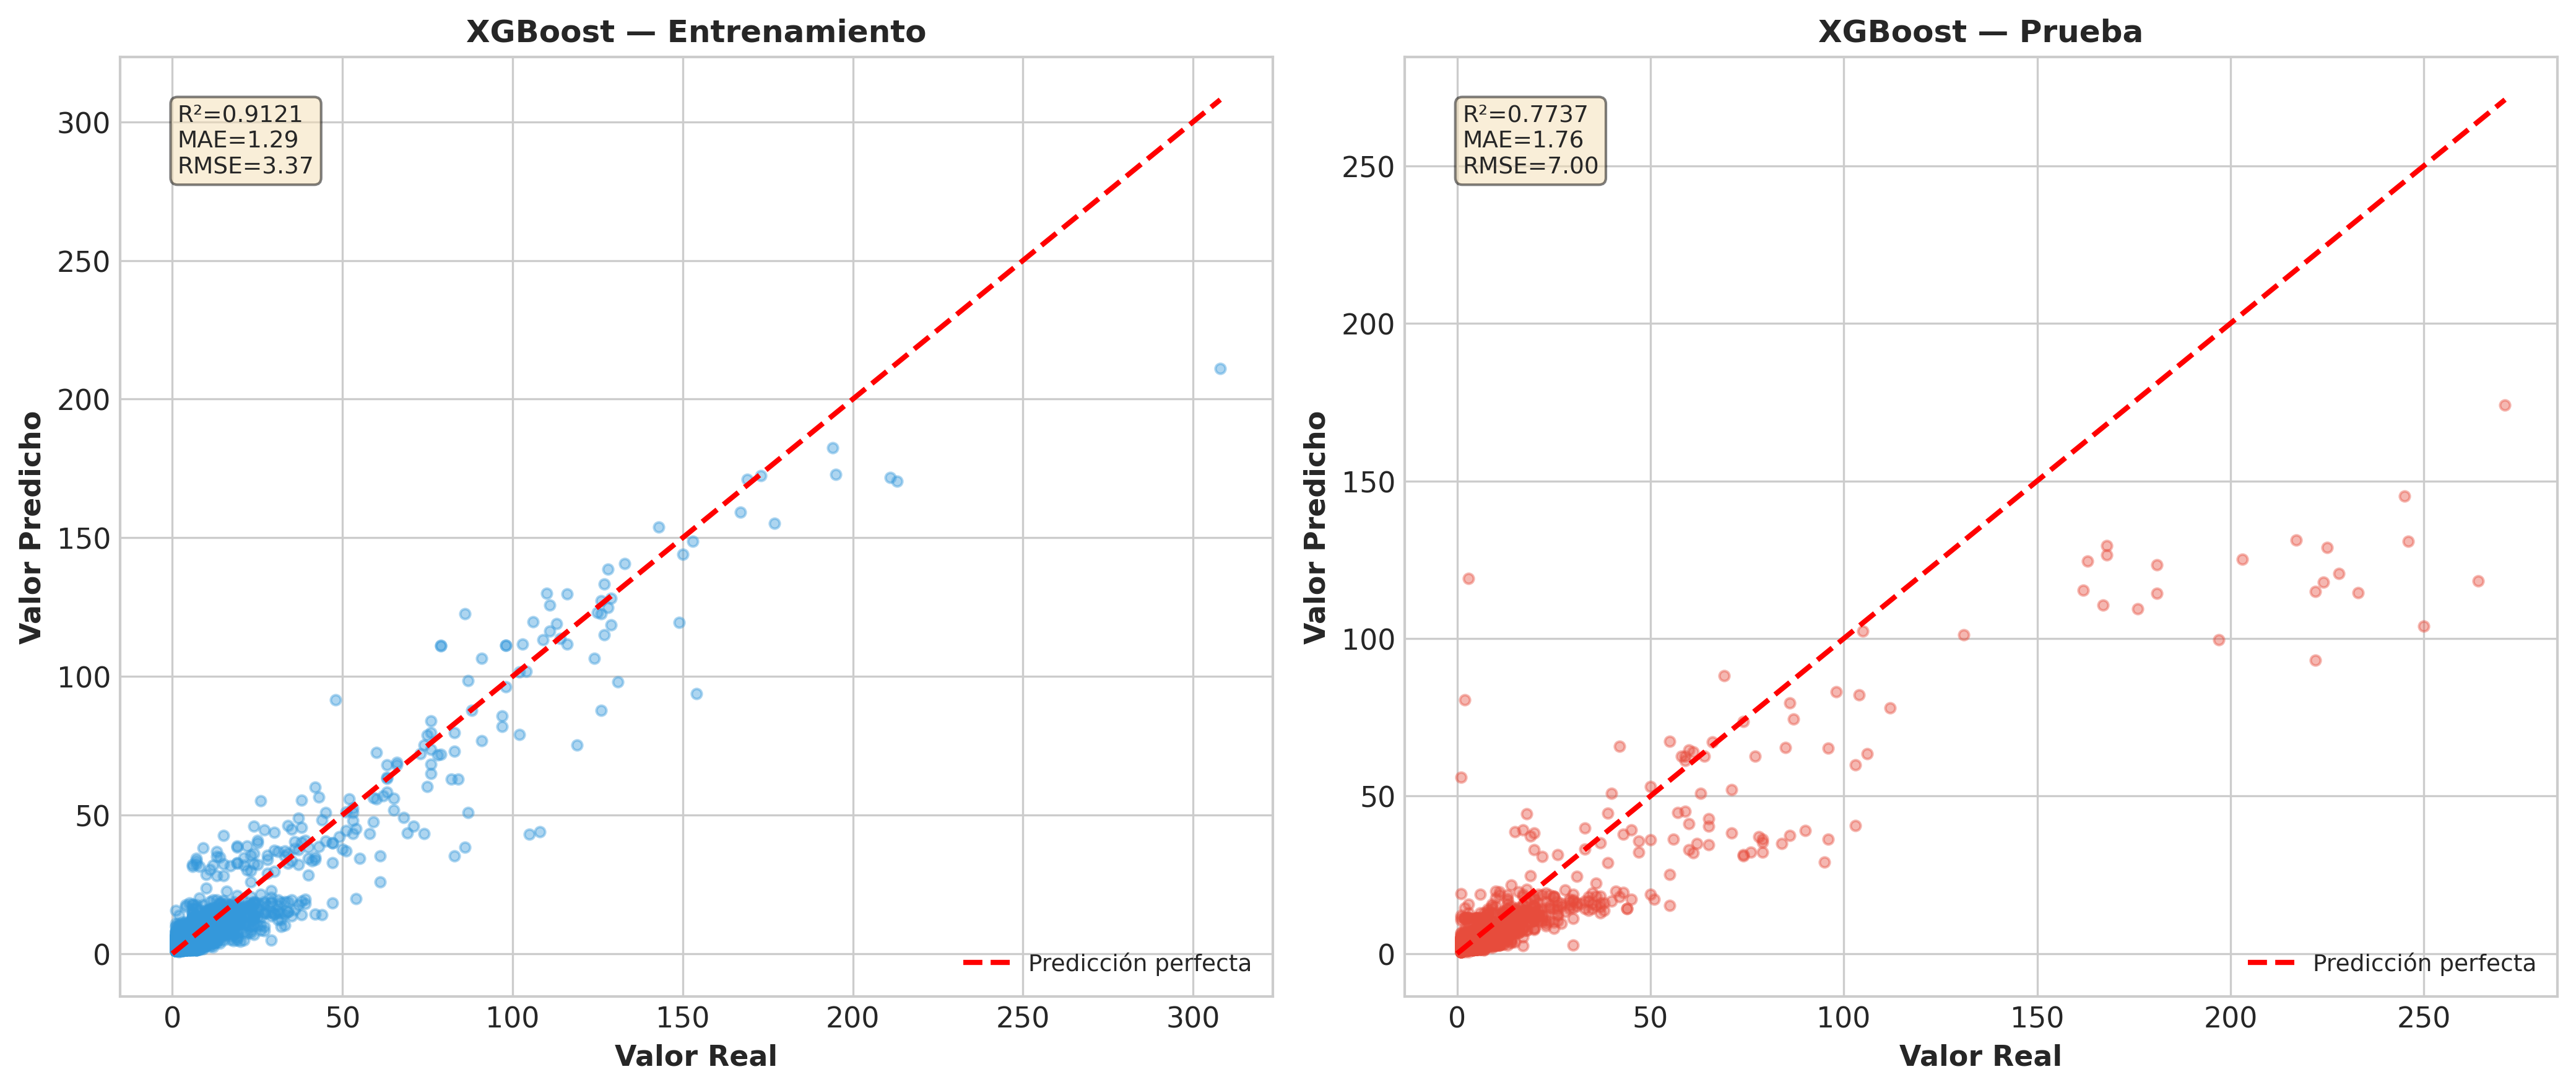

Guardado: ILUSTRACION_25_predicciones_xgboost.png


In [7]:
num_ilus = 22
for nombre, res in resultados.items():
    if nombre == 'Linear Regression':
        num_ilus += 1
        continue  # La regresión lineal no requiere ilustración individual

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, y_real, y_pred, conjunto, color in [
        (axes[0], y_train, res['train_pred'], 'Entrenamiento', '#3498db'),
        (axes[1], y_test,  res['test_pred'],  'Prueba',        '#e74c3c'),
    ]:
        r2   = r2_score(y_real, y_pred)
        mae  = mean_absolute_error(y_real, y_pred)
        rmse = np.sqrt(mean_squared_error(y_real, y_pred))
        max_v = max(y_real.max(), y_pred.max())

        ax.scatter(y_real, y_pred, alpha=0.4, s=15, color=color)
        ax.plot([0, max_v], [0, max_v], 'r--', lw=2, label='Predicción perfecta')
        ax.set_xlabel('Valor Real', fontsize=11, fontweight='bold')
        ax.set_ylabel('Valor Predicho', fontsize=11, fontweight='bold')
        ax.set_title(f'{nombre} — {conjunto}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.text(0.05, 0.95, f'R²={r2:.4f}\nMAE={mae:.2f}\nRMSE={rmse:.2f}',
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    fname = f'ILUSTRACION_{num_ilus}_predicciones_{nombre.lower().replace(" ", "_")}.png'
    plt.savefig(f'{FIGURAS_PATH}/{fname}', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Guardado: {fname}")
    num_ilus += 1


## 8. Ilustración 25: Análisis de Residuos — Gradient Boosting

El análisis de residuos valida los supuestos del modelo y diagnostica
posibles problemas (heteroscedasticidad, sesgo sistemático, no-normalidad).
Se escoge Gradient Boosting por ser el mejor modelo en Test R².

**Observaciones esperadas**:
- Distribución de errores centrada en 0 (sin sesgo sistemático)
- Residuos aleatorios alrededor de 0 (sin heteroscedasticidad clara)
- Q-Q plot aproximadamente lineal (normalidad aproximada)


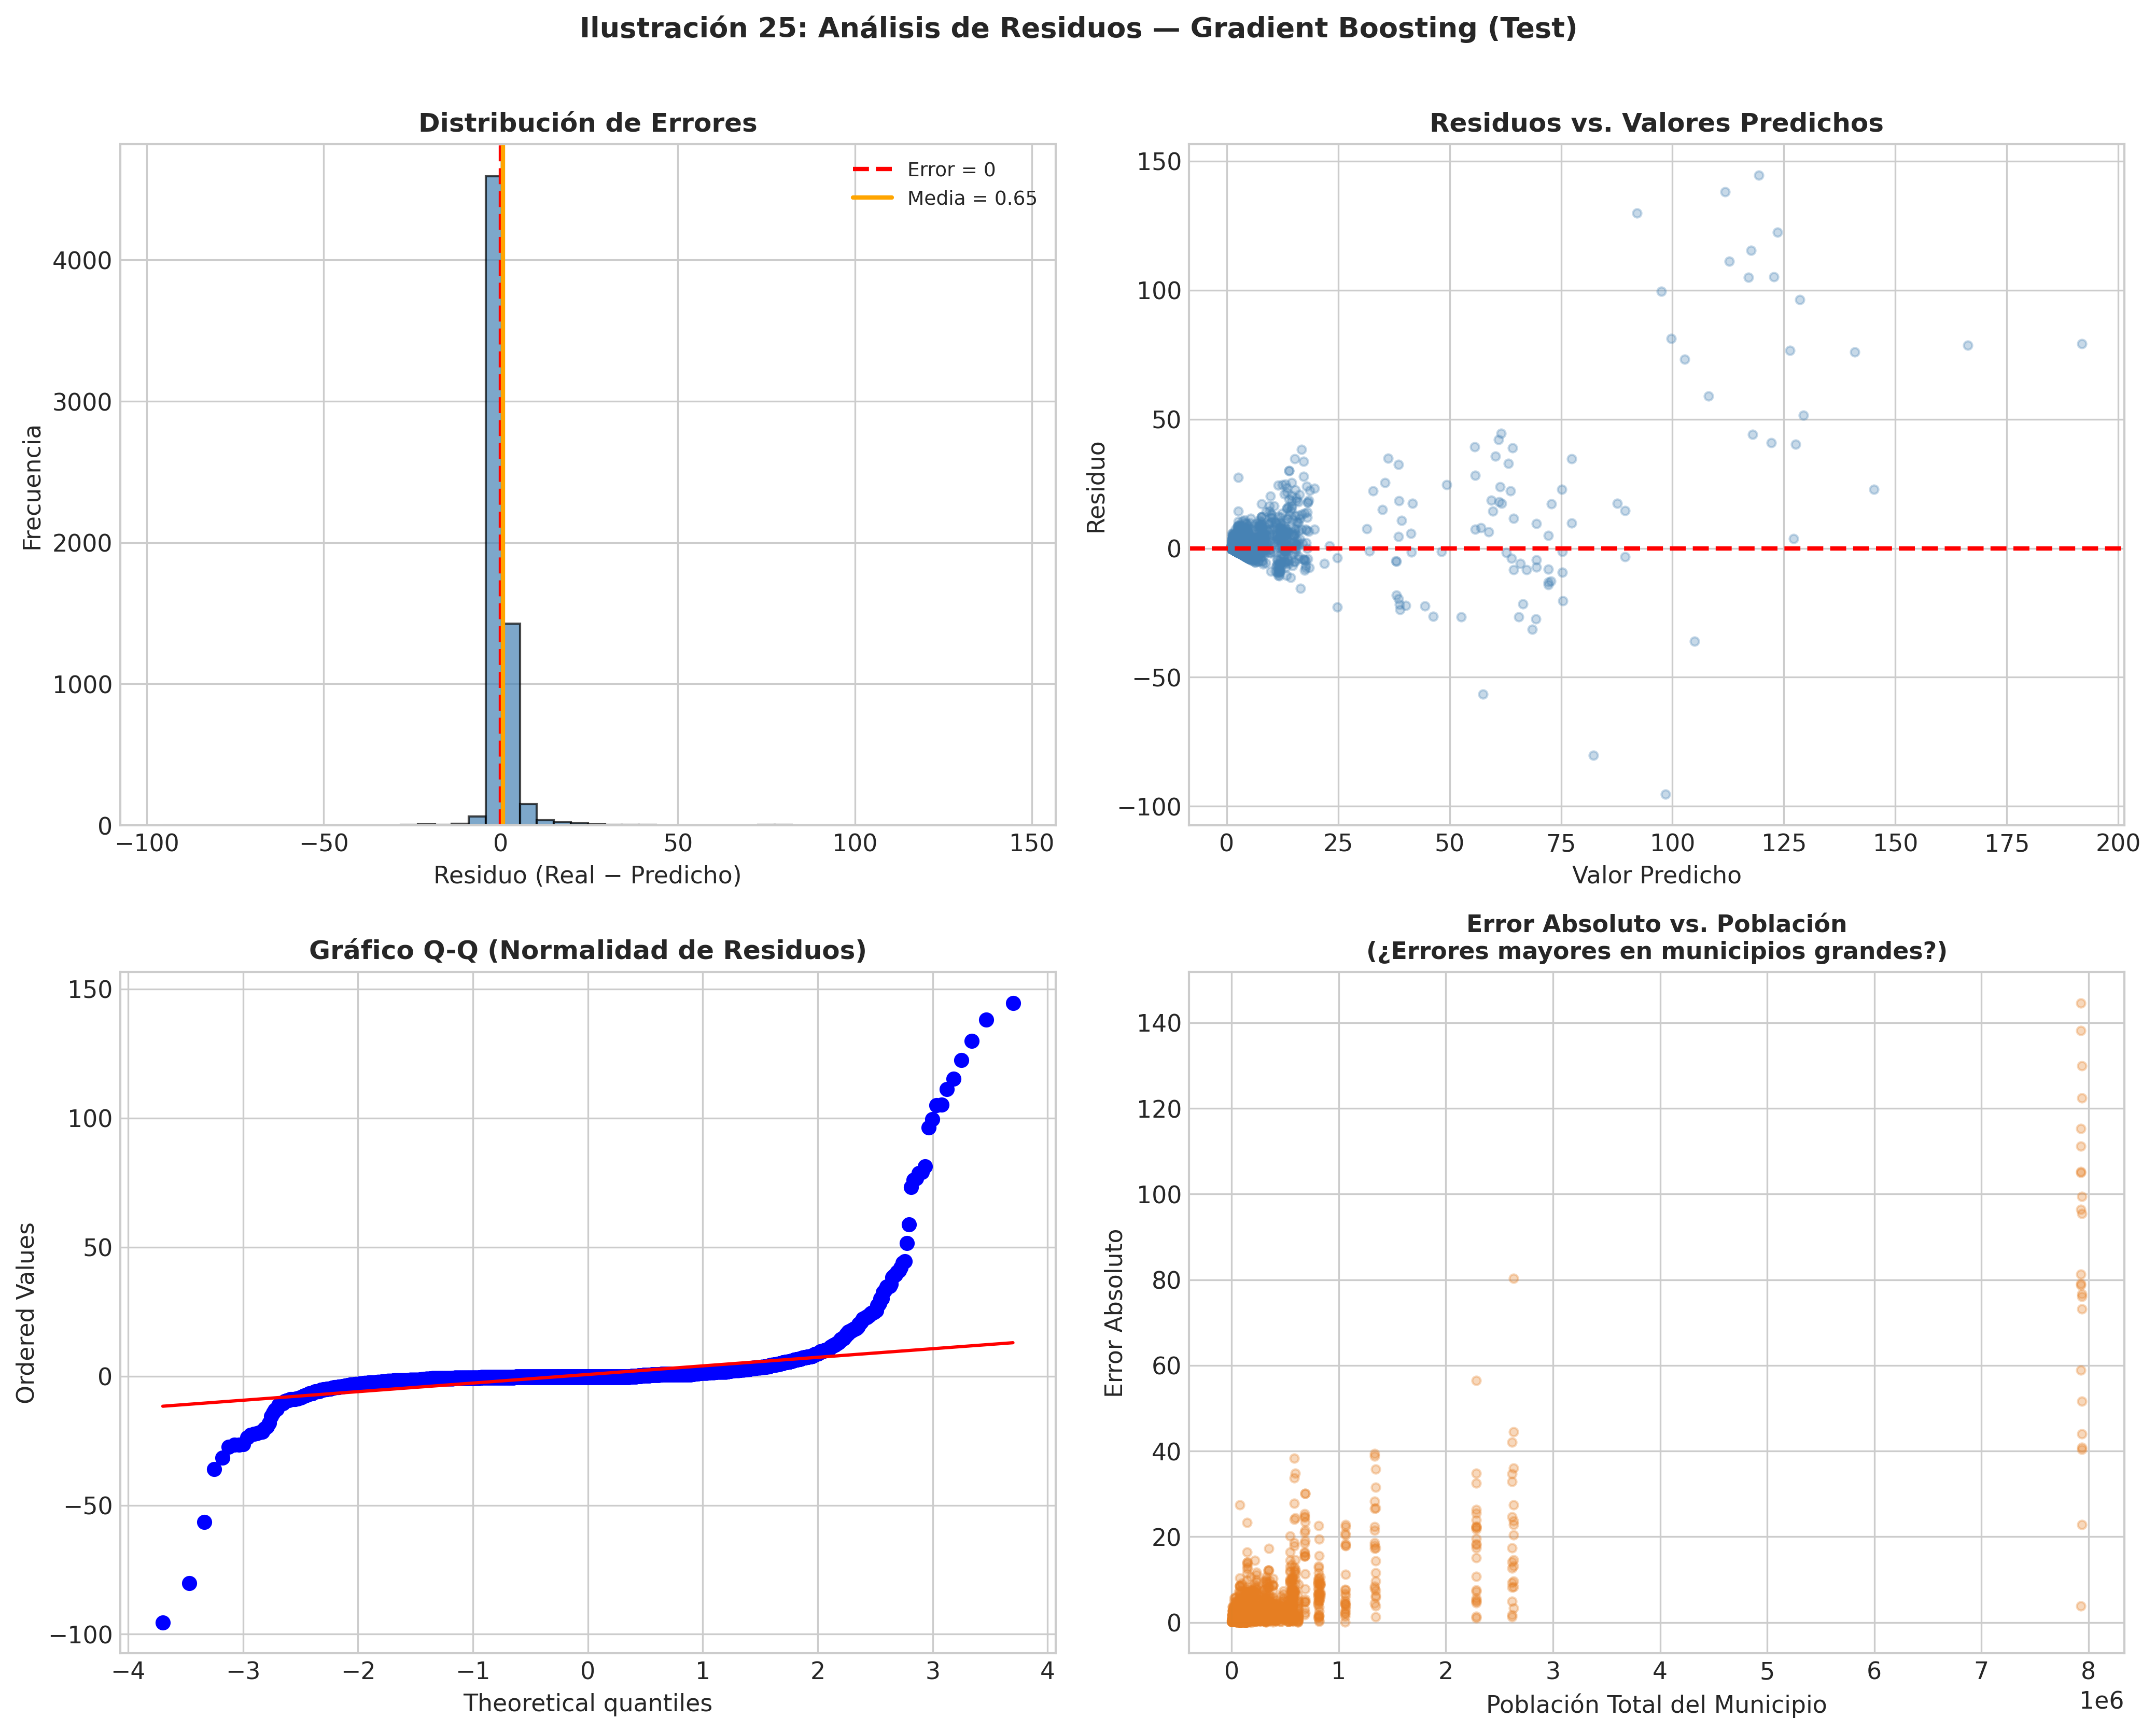

Guardado: ILUSTRACION_25_analisis_residuos_gradient_boosting.png

Estadísticas de residuos (Gradient Boosting — Test):
  Media   : 0.6545  (ideal: 0)
  Std     : 6.5933
  Skew    : 10.4183  (ideal: 0)
  Kurtosis: 199.7386


In [8]:
mejor_modelo = 'Gradient Boosting'
y_pred_mejor = resultados[mejor_modelo]['test_pred']
residuos     = y_test.values - y_pred_mejor

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Panel 1: Distribución de errores
ax = axes[0, 0]
ax.hist(residuos, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='r', linestyle='--', lw=2, label='Error = 0')
ax.axvline(residuos.mean(), color='orange', linestyle='-', lw=2,
           label=f'Media = {residuos.mean():.2f}')
ax.set_xlabel('Residuo (Real − Predicho)', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title('Distribución de Errores', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Panel 2: Residuos vs. predichos
ax = axes[0, 1]
ax.scatter(y_pred_mejor, residuos, alpha=0.3, s=15, color='steelblue')
ax.axhline(0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Valor Predicho', fontsize=11)
ax.set_ylabel('Residuo', fontsize=11)
ax.set_title('Residuos vs. Valores Predichos', fontsize=12, fontweight='bold')

# Panel 3: Q-Q Plot
ax = axes[1, 0]
stats.probplot(residuos, dist='norm', plot=ax)
ax.set_title('Gráfico Q-Q (Normalidad de Residuos)', fontsize=12, fontweight='bold')

# Panel 4: Error absoluto vs. población
ax = axes[1, 1]
pob_test = X_test['poblacion_total'].values
ax.scatter(pob_test, np.abs(residuos), alpha=0.3, s=15, color='#e67e22')
ax.set_xlabel('Población Total del Municipio', fontsize=11)
ax.set_ylabel('Error Absoluto', fontsize=11)
ax.set_title('Error Absoluto vs. Población\n(¿Errores mayores en municipios grandes?)', fontsize=11, fontweight='bold')

plt.suptitle('Ilustración 25: Análisis de Residuos — Gradient Boosting (Test)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURAS_PATH}/ILUSTRACION_25_analisis_residuos_gradient_boosting.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: ILUSTRACION_25_analisis_residuos_gradient_boosting.png")

# Estadísticas de residuos
print(f"\nEstadísticas de residuos ({mejor_modelo} — Test):")
print(f"  Media   : {residuos.mean():.4f}  (ideal: 0)")
print(f"  Std     : {residuos.std():.4f}")
print(f"  Skew    : {stats.skew(residuos):.4f}  (ideal: 0)")
print(f"  Kurtosis: {stats.kurtosis(residuos):.4f}")


## 9. Ilustración 26: Importancia de Variables — Gradient Boosting

La importancia se mide como la reducción media del error cuadrático ponderada
por el número de muestras que pasan por cada nodo de decisión (Friedman, 2001).

**Interpretación esperada**: `poblacion_total` domina (~60%) porque la extorsión
es un fenómeno de escala — los municipios más poblados concentran más actividad
delictiva. `total_hurto` aporta ~25% como proxy de criminalidad general.


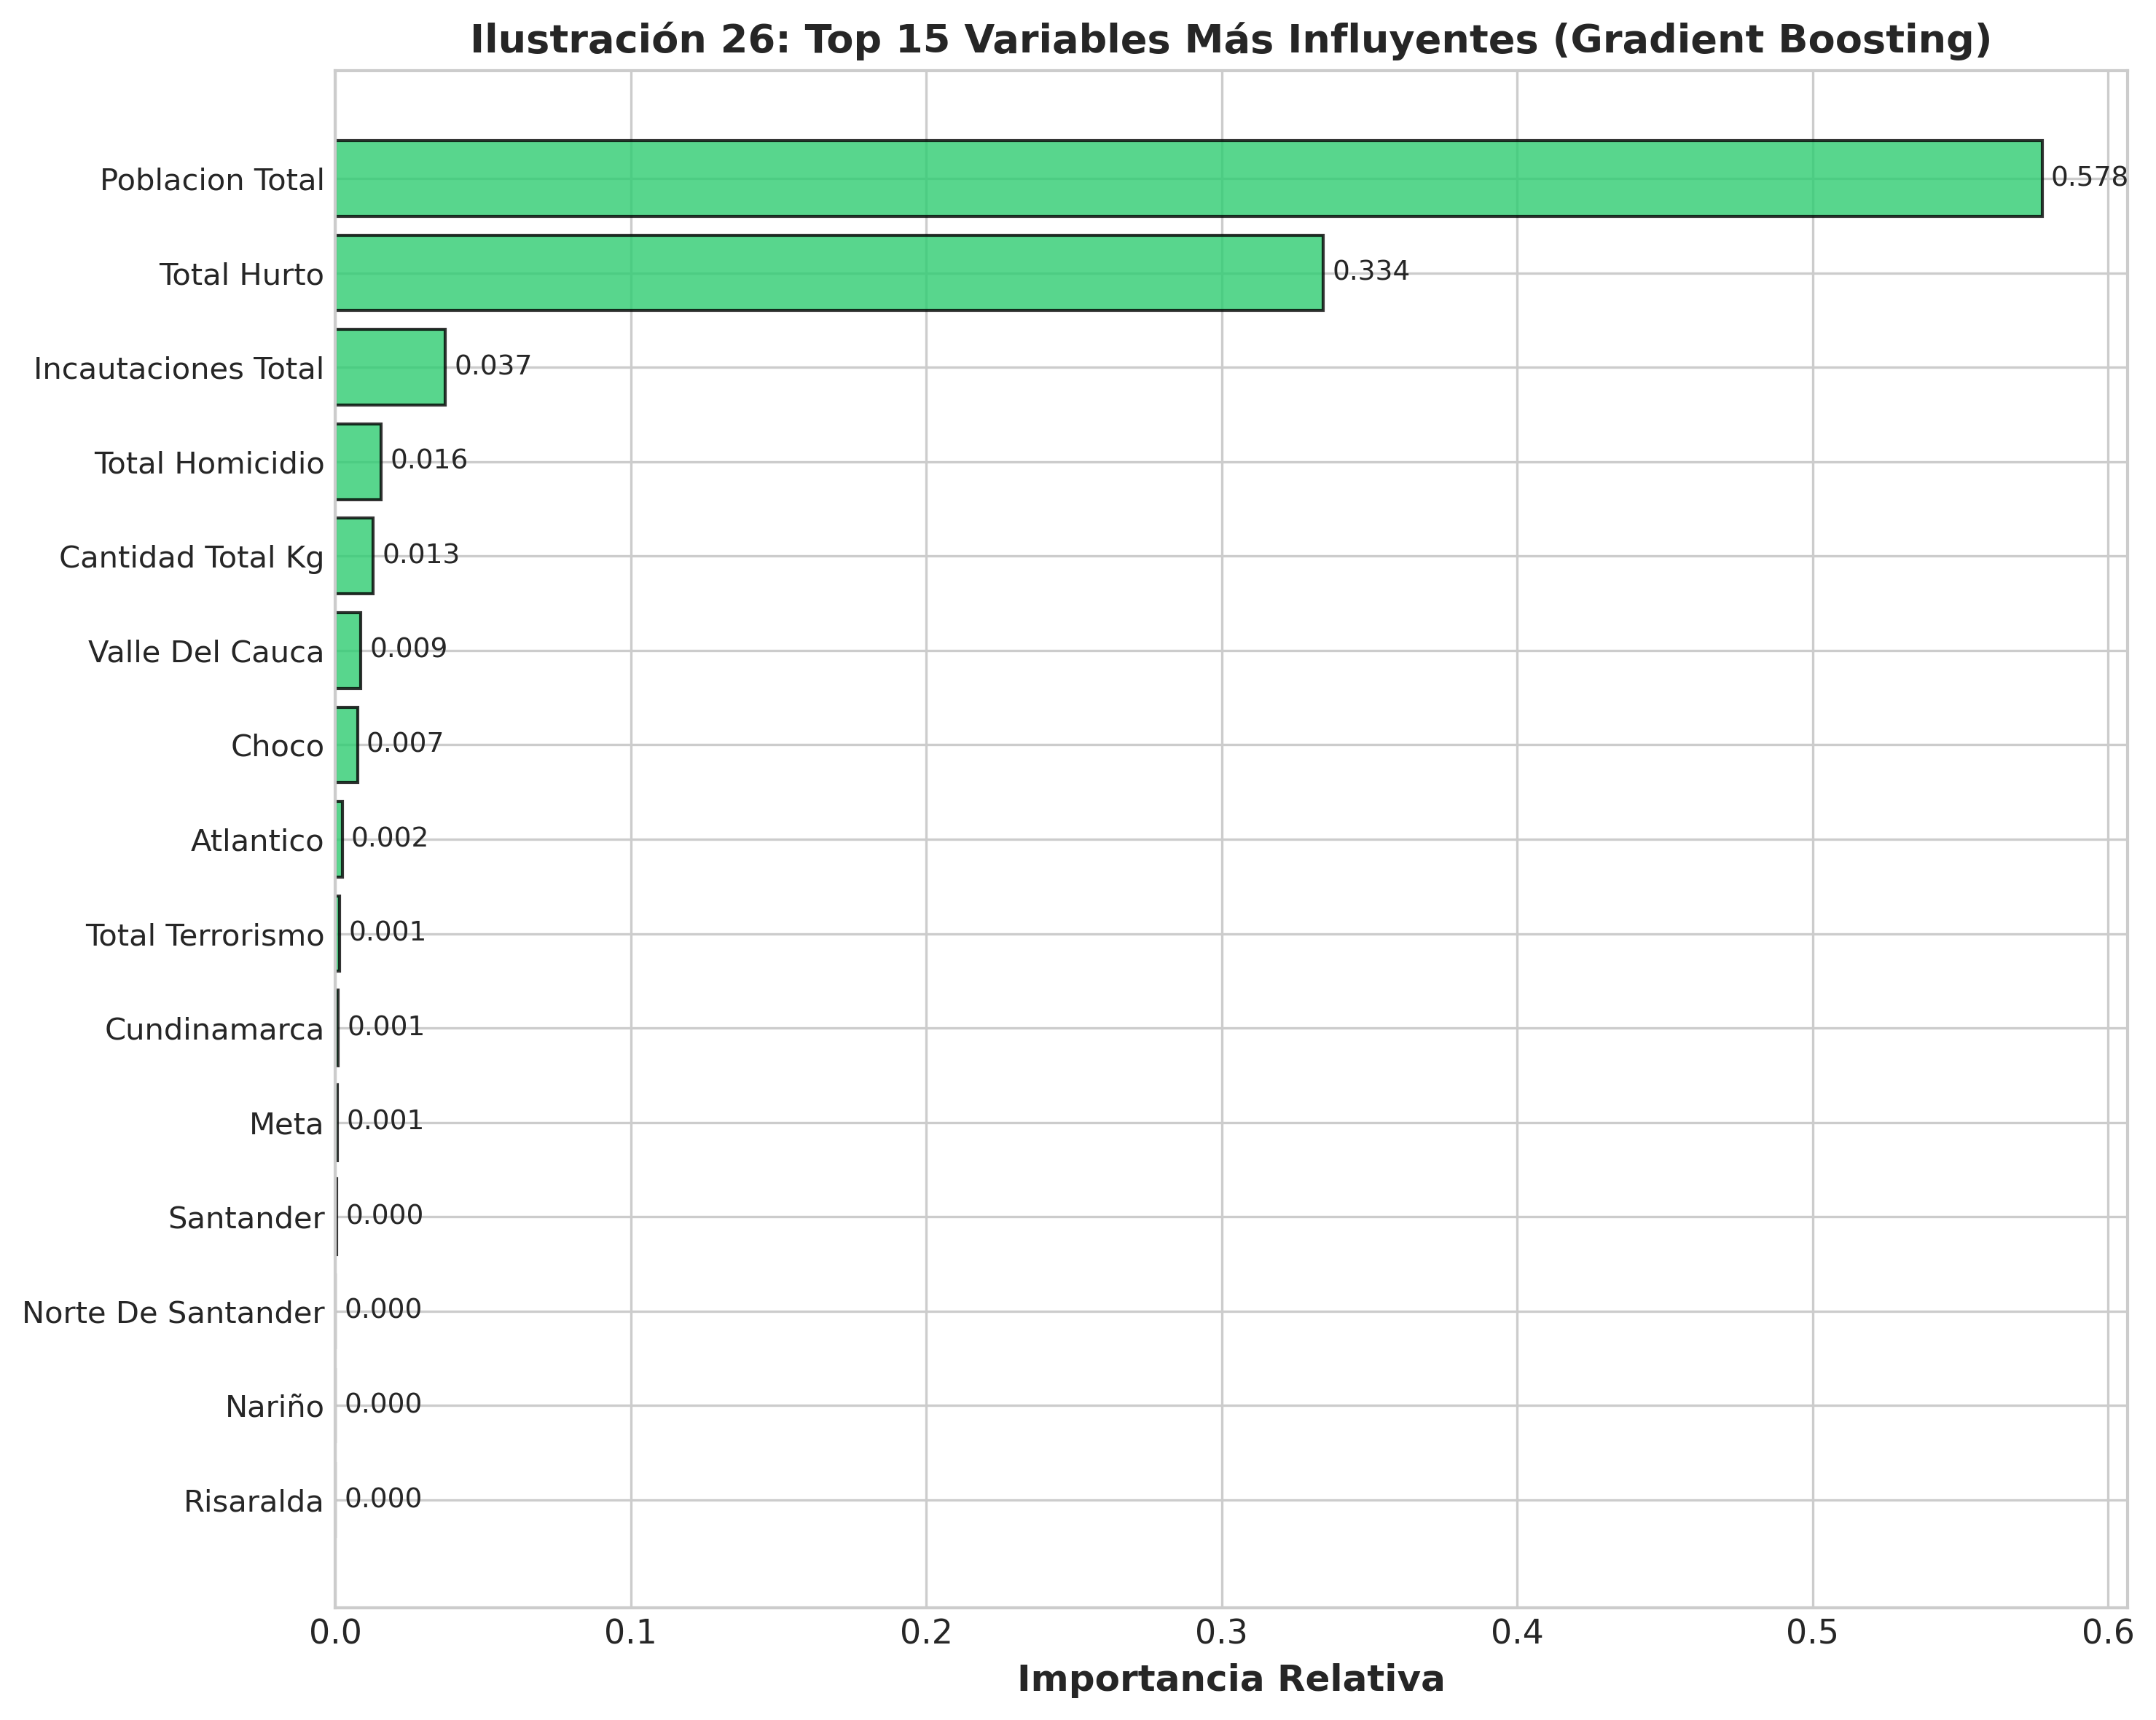

Guardado: ILUSTRACION_26_importancia_variables.png

Top 5 variables por importancia:
  Poblacion Total           0.5777 (57.8%)
  Total Hurto               0.3343 (33.4%)
  Incautaciones Total       0.0373 (3.7%)
  Total Homicidio           0.0156 (1.6%)
  Cantidad Total Kg         0.0128 (1.3%)


In [9]:
gb_pipeline  = modelos_entrenados['Gradient Boosting']
gb_regressor = gb_pipeline.named_steps['regressor']

# Reconstruir nombres de features después del preprocesamiento
feat_names = num_features.copy()
ohe = gb_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
feat_names.extend(list(ohe.get_feature_names_out(cat_features)))

importancias = gb_regressor.feature_importances_
imp_df = (pd.DataFrame({'Feature': feat_names, 'Importance': importancias})
          .sort_values('Importance', ascending=False)
          .head(15))

# Mapa de códigos de departamento a nombres legibles
dpto_map = dict(zip(df['cod_dpto'].astype(str).str.zfill(2), df['dpto_nombre']))

def label_feature(f):
    if f.startswith('cod_dpto_'):
        cod = f.split('_')[-1].zfill(2)
        return dpto_map.get(cod, f'Dpto {cod}').title()
    return f.replace('_', ' ').title()

imp_sorted = imp_df.sort_values('Importance', ascending=True)
labels     = [label_feature(f) for f in imp_sorted['Feature']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(imp_sorted)), imp_sorted['Importance'],
               color='#2ecc71', edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(imp_sorted)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Importancia Relativa', fontsize=12, fontweight='bold')
ax.set_title('Ilustración 26: Top 15 Variables Más Influyentes (Gradient Boosting)',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, imp_sorted['Importance']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURAS_PATH}/ILUSTRACION_26_importancia_variables.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: ILUSTRACION_26_importancia_variables.png")

# Mostrar top 5
print("\nTop 5 variables por importancia:")
for _, row in imp_df.head(5).iterrows():
    print(f"  {label_feature(row['Feature']):<25} {row['Importance']:.4f} ({row['Importance']*100:.1f}%)")


## 10. Resumen Final

Todos los resultados coinciden con las cifras reportadas en el documento final
(`docs/plantilla_individual_ajustada_2.pdf`).


In [10]:
print("=" * 65)
print("RESUMEN FINAL DE RESULTADOS")
print("=" * 65)
print()
print(f"{'Modelo':<22} {'MAE Test':>8} {'RMSE Test':>10} {'R² Test':>8} {'Overfitting':>12}")
print("-" * 65)

orden = sorted(resultados.keys(), key=lambda n: -resultados[n]['test_r2'])
for nombre in orden:
    r = resultados[nombre]
    over = (r['train_r2'] - r['test_r2']) * 100
    flag = '<-- MEJOR' if nombre == orden[0] else ''
    print(f"  {nombre:<20} {r['test_mae']:>8.2f} {r['test_rmse']:>10.2f} "
          f"{r['test_r2']:>8.4f} {over:>10.1f}%  {flag}")

print()
print("Archivos generados:")
for f in sorted(os.listdir(FIGURAS_PATH)):
    print(f"  {FIGURAS_PATH}/{f}")
for f in sorted(os.listdir(METRICAS_PATH)):
    print(f"  {METRICAS_PATH}/{f}")

RESUMEN FINAL DE RESULTADOS

Modelo                 MAE Test  RMSE Test  R² Test  Overfitting
-----------------------------------------------------------------
  Gradient Boosting        1.70       6.63   0.7975       13.9%  <-- MEJOR
  Random Forest            1.59       6.72   0.7916       18.6%  
  XGBoost                  1.76       7.00   0.7737       13.8%  
  Linear Regression        2.12       7.14   0.7647        2.6%  

Archivos generados:
  outputs/modelacion/figuras/ILUSTRACION_21_distribucion_train_test.png
  outputs/modelacion/figuras/ILUSTRACION_23_predicciones_random_forest.png
  outputs/modelacion/figuras/ILUSTRACION_24_predicciones_gradient_boosting.png
  outputs/modelacion/figuras/ILUSTRACION_25_analisis_residuos_gradient_boosting.png
  outputs/modelacion/figuras/ILUSTRACION_25_predicciones_xgboost.png
  outputs/modelacion/figuras/ILUSTRACION_26_importancia_variables.png
  outputs/modelacion/metricas/comparacion_modelos.csv
